# Multimodal Cancer Classification Challenge 2026 — v13

**v11 LB = 0.6479. v12 LB = 0.6059 (regression).** Per-image normalization + heavy color aug helped CV stability but actively hurt LB. So v13 reverts everything to v11 and adds **only one** new thing: **self-supervised pretraining on the unlabelled test images** (the path the competition host explicitly recommends in the dataset description).

**Strategy: v11 + SSL only. Clean ablation.**

Stage 1 — SSL pretraining (~30 min):
- Train a single ResNet-18 backbone on **all 173k cell pairs (train + test)** via **4-way rotation prediction**: each (BF, FL) pair is rotated by k×90° (k ∈ {0,1,2,3}) and the model predicts k. This is the simplest SSL task that has been shown to learn useful features for medical imaging, and it requires no labels.
- The backbone learns features that capture cell *structure* (which is rotation-invariant in nature, so the network has to actually look at content) rather than patient-specific staining baselines.
- The encoder weights from this stage replace ImageNet init for the supervised stage.

Stage 2 — Supervised training (v11 settings, unchanged):
- 3 folds × 2 seeds = 6 CV models + 1 full-data model
- ResNet-18 backbone, initialised from the SSL stage instead of ImageNet
- Patient-balanced sampler, D4 augmentation, mild ColorJitter, Mixup α=0.1
- BCE + pos_weight, OneCycleLR, AMP, grad clip, 8-way D4 TTA
- AUC-gated ensemble at val_auc ≥ 0.78, full-data model always included

**What was reverted from v12:** per-image normalization (back to dataset BF/FL stats), strong ColorJitter (back to 0.2), RandomGamma (removed), Gaussian noise (removed), CutMix (back to Mixup α=0.1), DropPath (removed for clean comparison).

Runtime: ~30 min cache + ~30 min SSL + ~2.5 h supervised + ~30 min TTA = **~4 h total**.

Kaggle settings: Accelerator = GPU T4 x2 (use only GPU 0), Internet On, Persistence = Files only.

In [1]:
import os
os.environ["PYTHONUNBUFFERED"] = "1"

import re, io, json, time, random, glob, functools, gc
from pathlib import Path

print = functools.partial(print, flush=True)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from PIL import Image
import matplotlib.pyplot as plt

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available(),
      "n_gpu:", torch.cuda.device_count())
!nvidia-smi -L

torch: 2.10.0+cu128 cuda: True n_gpu: 2
GPU 0: Tesla T4 (UUID: GPU-d5e72afa-611b-fa68-ddef-eb730be57bd2)
GPU 1: Tesla T4 (UUID: GPU-c00c6ab5-6631-6d6c-1be7-832cecc79099)


In [2]:
DATA_ROOT = Path("/kaggle/input/datasets/rafaelproena/a3-adl")
assert (DATA_ROOT / "train.csv").exists(), f"train.csv not at {DATA_ROOT}"
print("DATA_ROOT =", DATA_ROOT)

OUT_DIR = Path("/kaggle/working/runs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# CV (same as v11)
N_SPLITS    = 3
BASE_SEED   = 1
SEEDS       = [1, 2]

# Supervised optimization (same as v11)
EPOCHS      = 10
PATIENCE    = 5
BATCH_SIZE  = 128
LR          = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP   = 1.0
MIXUP_ALPHA = 0.1
DROPOUT     = 0.3

# SSL pretraining (new in v13)
# After analyzing v12: more SSL epochs = better init for fold 2 recovery
SSL_ENABLED  = True
SSL_EPOCHS   = 6                    # bumped 4→6 based on v12 analysis
SSL_LR       = 1e-3
SSL_BATCH    = 384                  # bumped 256→384: rotation task is light, T4 can take it
SSL_CKPT     = OUT_DIR / "ssl_backbone.pt"

# Sampler
NUM_WORKERS = 2
PATIENTS_PER_BATCH = 4

# Full-data model
TRAIN_FULL_DATA_MODEL = True

# Ensemble gate
ENSEMBLE_MIN_AUC = 0.78

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    torch.cuda.set_device(0)

# Dataset-level normalization (v11 stats, NOT v12 per-image)
BF_MEAN, BF_STD = 0.504, 0.216
FL_MEAN, FL_STD = 0.100, 0.144

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(BASE_SEED)

DATA_ROOT = /kaggle/input/datasets/rafaelproena/a3-adl


In [3]:
PAT_RE = re.compile(r"^pat_(\d+)_image_\d+\.jpg$")

def parse_patient_id(filename):
    m = PAT_RE.match(Path(filename).name)
    return int(m.group(1)) if m else None

def load_train_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    df["patient_id"] = df["Name"].map(parse_patient_id).astype(int)
    return df

def load_test_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    return df

def cache_split(names, bf_dir, fl_dir, label=""):
    bf_dir, fl_dir = Path(bf_dir), Path(fl_dir)
    bf, fl = {}, {}
    t0 = time.time()
    for i, n in enumerate(names):
        with open(bf_dir / n, "rb") as f: bf[n] = f.read()
        with open(fl_dir / n, "rb") as f: fl[n] = f.read()
        if (i + 1) % 20000 == 0:
            print(f"  [{label}] cached {i+1}/{len(names)} in {time.time()-t0:.1f}s")
    print(f"  [{label}] cached {len(names)} in {time.time()-t0:.1f}s")
    return bf, fl

class CachedCellDataset(Dataset):
    """Supervised dataset (same as v11). Returns dict with bf, fl, label, name."""
    def __init__(self, df, bf_cache, fl_cache, bf_tf, fl_tf, paired_tf=None):
        self.df = df.reset_index(drop=True)
        self.bf_cache = bf_cache; self.fl_cache = fl_cache
        self.bf_tf = bf_tf; self.fl_tf = fl_tf
        self.paired_tf = paired_tf

    def __len__(self): return len(self.df)

    @staticmethod
    def _decode(buf): return Image.open(io.BytesIO(buf)).convert("L")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]; name = row["Name"]
        bf = self.bf_tf(self._decode(self.bf_cache[name]))
        fl = self.fl_tf(self._decode(self.fl_cache[name]))
        if self.paired_tf is not None:
            bf, fl = self.paired_tf(bf, fl)
        label = int(row["Diagnosis"]) if "Diagnosis" in row else -1
        return {"bf": bf, "fl": fl, "label": label, "name": name}

class SSLRotationDataset(Dataset):
    """SSL dataset for 4-way rotation prediction.
    Yields (bf_rot, fl_rot, k) where k ∈ {0,1,2,3} is the rotation applied to
    BOTH modalities (same k, to preserve cross-modal alignment). The supervised
    head will predict k. No D4 augmentation here — that would defeat the purpose.
    """
    def __init__(self, all_pairs, bf_caches, fl_caches, bf_tf, fl_tf):
        # all_pairs is a list of (name, split) where split is 'train' or 'test'
        self.pairs = all_pairs
        self.bf_caches = bf_caches      # dict: 'train' / 'test' -> dict of bytes
        self.fl_caches = fl_caches
        self.bf_tf = bf_tf; self.fl_tf = fl_tf

    def __len__(self): return len(self.pairs)

    @staticmethod
    def _decode(buf): return Image.open(io.BytesIO(buf)).convert("L")

    def __getitem__(self, idx):
        name, split = self.pairs[idx]
        bf = self.bf_tf(self._decode(self.bf_caches[split][name]))
        fl = self.fl_tf(self._decode(self.fl_caches[split][name]))
        # Apply same rotation to both modalities (cross-modal alignment preserved).
        k = random.randint(0, 3)
        if k:
            bf = torch.rot90(bf, k, dims=(-2, -1))
            fl = torch.rot90(fl, k, dims=(-2, -1))
        # Light horizontal flip (50% chance) — does not affect rotation label.
        if random.random() < 0.5:
            bf, fl = TF.hflip(bf), TF.hflip(fl)
        return {"bf": bf, "fl": fl, "rot": k}

In [4]:
def stratified_patient_kfold(df, n_splits=3, seed=1):
    skgf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y = df["Diagnosis"].to_numpy(); groups = df["patient_id"].to_numpy()
    splits = list(skgf.split(df, y=y, groups=groups))
    for f, (_, va) in enumerate(splits):
        if len(np.unique(y[va])) < 2:
            raise ValueError(f"Fold {f} has only one class — try another seed.")
    return splits

def summarize_split(df, tr, va):
    trd, vad = df.iloc[tr], df.iloc[va]
    return (f"train: {len(tr):>6} cells, {trd['patient_id'].nunique():>2}p, "
            f"pos {trd['Diagnosis'].mean():.3f} | "
            f"val: {len(va):>6} cells, {vad['patient_id'].nunique():>2}p, "
            f"pos {vad['Diagnosis'].mean():.3f} | "
            f"val pats: {sorted(vad['patient_id'].unique().tolist())}")

class PatientBalancedSampler(Sampler):
    def __init__(self, df, batch_size, patients_per_batch=4, seed=0):
        assert batch_size % patients_per_batch == 0
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.per_pat = batch_size // patients_per_batch
        self.patients_per_batch = patients_per_batch
        self.rng = np.random.default_rng(seed)
        self.by_pat = {p: np.array(g.index.tolist())
                       for p, g in self.df.groupby("patient_id")}
        self.patients = list(self.by_pat.keys())
        self.epoch_len = len(self.df) // batch_size * batch_size

    def __len__(self): return self.epoch_len

    def __iter__(self):
        out = []
        for _ in range(self.epoch_len // self.batch_size):
            pats = self.rng.choice(self.patients,
                                   size=min(self.patients_per_batch, len(self.patients)),
                                   replace=False)
            for p in pats:
                idxs = self.by_pat[p]
                out.extend(self.rng.choice(idxs, size=self.per_pat,
                                           replace=len(idxs) < self.per_pat).tolist())
        return iter(out)

In [5]:
# v11 transforms (dataset-level normalization, mild ColorJitter)
def _to_tensor_norm(mean, std):
    def fn(img):
        t = TF.to_tensor(img)
        return TF.normalize(t, [mean], [std])
    return fn

to_tensor_bf = _to_tensor_norm(BF_MEAN, BF_STD)
to_tensor_fl = _to_tensor_norm(FL_MEAN, FL_STD)

class PairedGeoAug:
    """Identical geometric augmentation on BF and FL (D4 + small rotation)."""
    def __init__(self, p_hflip=0.5, p_vflip=0.5, rot90=True, max_rot=10.0):
        self.p_hflip = p_hflip; self.p_vflip = p_vflip
        self.rot90 = rot90; self.max_rot = max_rot

    def __call__(self, bf, fl):
        if self.rot90:
            k = random.randint(0, 3)
            if k:
                bf = torch.rot90(bf, k, dims=(-2, -1))
                fl = torch.rot90(fl, k, dims=(-2, -1))
        if random.random() < self.p_hflip: bf, fl = TF.hflip(bf), TF.hflip(fl)
        if random.random() < self.p_vflip: bf, fl = TF.vflip(bf), TF.vflip(fl)
        if self.max_rot > 0:
            a = random.uniform(-self.max_rot, self.max_rot)
            bf, fl = TF.rotate(bf, a), TF.rotate(fl, a)
        return bf, fl

def train_modality_transform(modality):
    norm = to_tensor_bf if modality == "bf" else to_tensor_fl
    return T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2), norm])

def eval_modality_transform(modality):
    return to_tensor_bf if modality == "bf" else to_tensor_fl

# SSL transforms — NO D4 (would destroy the rotation label), mild color only.
def ssl_modality_transform(modality):
    norm = to_tensor_bf if modality == "bf" else to_tensor_fl
    return T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2), norm])

In [6]:
def _make_resnet18_branch(pretrained=True):
    weights = "DEFAULT" if pretrained else None
    net = models.resnet18(weights=weights)
    w = net.conv1.weight.data
    new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    if pretrained:
        new_conv.weight.data = w.mean(dim=1, keepdim=True)
    net.conv1 = new_conv
    fd = net.fc.in_features; net.fc = nn.Identity()
    return net, fd  # 512

class MultimodalClassifier(nn.Module):
    """Same as v11: two ResNet-18 branches + concat fusion head, BCE output."""
    def __init__(self, pretrained=True, dropout=DROPOUT):
        super().__init__()
        self.bf_branch, fd = _make_resnet18_branch(pretrained)
        self.fl_branch, _  = _make_resnet18_branch(pretrained)
        self.head = nn.Sequential(
            nn.Linear(fd * 2, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(256, 1))

    def forward(self, bf, fl):
        feat = torch.cat([self.bf_branch(bf), self.fl_branch(fl)], dim=1)
        return self.head(feat).squeeze(-1)

class SSLRotationModel(nn.Module):
    """Two ResNet-18 branches + 4-class rotation head. The branches will be
    transferred into the supervised model after SSL pretraining."""
    def __init__(self, pretrained=True):
        super().__init__()
        self.bf_branch, fd = _make_resnet18_branch(pretrained)
        self.fl_branch, _  = _make_resnet18_branch(pretrained)
        self.rot_head = nn.Sequential(
            nn.Linear(fd * 2, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Linear(256, 4))

    def forward(self, bf, fl):
        feat = torch.cat([self.bf_branch(bf), self.fl_branch(fl)], dim=1)
        return self.rot_head(feat)

with torch.no_grad():
    _m = MultimodalClassifier(pretrained=False).cpu()
    _x = torch.zeros(2, 1, 128, 128)
    print("Supervised output shape:", _m(_x, _x).shape,
          "  params:", sum(p.numel() for p in _m.parameters()) // 1_000_000, "M")
    _s = SSLRotationModel(pretrained=False).cpu()
    print("SSL output shape:", _s(_x, _x).shape)
    del _m, _s, _x

Supervised output shape: torch.Size([2])   params: 22 M
SSL output shape: torch.Size([2, 4])


In [7]:
df_train = load_train_df(DATA_ROOT / "train.csv")
df_test  = load_test_df(DATA_ROOT / "sampleSubmission.csv")
print(f"Train: {len(df_train)} cells, {df_train['patient_id'].nunique()} patients, "
      f"pos rate {df_train['Diagnosis'].mean():.4f}")
print(f"Test:  {len(df_test)} cells")

print("\n--- Caching JPEG bytes into RAM ---")
bf_train_cache, fl_train_cache = cache_split(
    df_train["Name"].tolist(),
    DATA_ROOT / "BF" / "train", DATA_ROOT / "FL" / "train", label="train")
bf_test_cache, fl_test_cache = cache_split(
    df_test["Name"].tolist(),
    DATA_ROOT / "BF" / "test", DATA_ROOT / "FL" / "test", label="test")
approx_mb = (sum(len(b) for b in bf_train_cache.values()) +
             sum(len(b) for b in fl_train_cache.values()) +
             sum(len(b) for b in bf_test_cache.values()) +
             sum(len(b) for b in fl_test_cache.values())) / (1024 * 1024)
print(f"\nApprox RAM used by JPEG cache: {approx_mb:.0f} MB")

Train: 114302 cells, 12 patients, pos rate 0.3876
Test:  59040 cells

--- Caching JPEG bytes into RAM ---
  [train] cached 20000/114302 in 331.4s
  [train] cached 40000/114302 in 630.4s
  [train] cached 60000/114302 in 990.3s
  [train] cached 80000/114302 in 1312.2s
  [train] cached 100000/114302 in 1634.4s
  [train] cached 114302 in 1866.5s
  [test] cached 20000/59040 in 324.9s
  [test] cached 40000/59040 in 644.3s
  [test] cached 59040 in 935.8s

Approx RAM used by JPEG cache: 755 MB


In [8]:
# Stage 1 — Self-supervised rotation prediction on ALL images (train + test).
# Output: a ResNet-18 backbone (saved as `ssl_backbone.pt`) that will replace
# ImageNet initialization for the supervised stage.

def train_ssl_rotation(epochs=SSL_EPOCHS, batch_size=SSL_BATCH, lr=SSL_LR):
    seed_everything(BASE_SEED + 7)
    # Pool all train + test pairs together.
    all_pairs = ([(n, "train") for n in df_train["Name"].tolist()] +
                 [(n, "test")  for n in df_test["Name"].tolist()])
    print(f"SSL on {len(all_pairs)} cell pairs (train + test)")
    random.shuffle(all_pairs)

    bf_caches = {"train": bf_train_cache, "test": bf_test_cache}
    fl_caches = {"train": fl_train_cache, "test": fl_test_cache}
    ds = SSLRotationDataset(all_pairs, bf_caches, fl_caches,
                            ssl_modality_transform("bf"),
                            ssl_modality_transform("fl"))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    model = SSLRotationModel(pretrained=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(loader),
        epochs=epochs, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None

    for ep in range(epochs):
        t0 = time.time(); losses, correct, total = [], 0, 0
        model.train()
        for i, batch in enumerate(loader):
            bf = batch["bf"].to(DEVICE, non_blocking=True)
            fl = batch["fl"].to(DEVICE, non_blocking=True)
            rot = batch["rot"].to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=scaler is not None):
                logits = model(bf, fl)
                loss = criterion(logits, rot)
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                old_scale = scaler.get_scale()
                scaler.step(optimizer); scaler.update()
                if scaler.get_scale() >= old_scale: sched.step()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); sched.step()
            losses.append(loss.item())
            correct += (logits.argmax(1) == rot).sum().item()
            total += rot.size(0)
            if (i + 1) % 100 == 0:
                print(f"    step {i+1}/{len(loader)} | loss {np.mean(losses[-100:]):.4f} "
                      f"| acc {correct/total:.3f}")
        print(f"  SSL ep {ep} | loss {np.mean(losses):.4f} | acc {correct/total:.3f} | {time.time()-t0:.1f}s")

    # Save the two branch state dicts (everything except the rotation head).
    torch.save({"bf_branch": model.bf_branch.state_dict(),
                "fl_branch": model.fl_branch.state_dict()}, SSL_CKPT)
    print(f"Saved SSL backbone to {SSL_CKPT}")
    del model, optimizer, sched, scaler, loader, ds
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

if SSL_ENABLED:
    print("=== Stage 1: SSL rotation pretraining ===")
    train_ssl_rotation()
else:
    print("(SSL disabled — supervised training will use ImageNet init)")

=== Stage 1: SSL rotation pretraining ===
SSL on 173342 cell pairs (train + test)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


    step 100/451 | loss 1.2889 | acc 0.365
    step 200/451 | loss 0.8741 | acc 0.488
    step 300/451 | loss 0.7537 | acc 0.545
    step 400/451 | loss 0.6700 | acc 0.580
  SSL ep 0 | loss 0.8692 | acc 0.592 | 201.1s
    step 100/451 | loss 0.6089 | acc 0.705
    step 200/451 | loss 0.5787 | acc 0.710
    step 300/451 | loss 0.5616 | acc 0.715
    step 400/451 | loss 0.5049 | acc 0.727
  SSL ep 1 | loss 0.5556 | acc 0.732 | 199.6s
    step 100/451 | loss 0.4752 | acc 0.779
    step 200/451 | loss 0.4643 | acc 0.782
    step 300/451 | loss 0.4519 | acc 0.785
    step 400/451 | loss 0.4404 | acc 0.787
  SSL ep 2 | loss 0.4558 | acc 0.788 | 205.2s
    step 100/451 | loss 0.4356 | acc 0.797
    step 200/451 | loss 0.4243 | acc 0.800
    step 300/451 | loss 0.4198 | acc 0.802
    step 400/451 | loss 0.4116 | acc 0.804
  SSL ep 3 | loss 0.4218 | acc 0.804 | 199.1s
    step 100/451 | loss 0.4004 | acc 0.815
    step 200/451 | loss 0.3918 | acc 0.818
    step 300/451 | loss 0.3775 | acc 0.821

In [9]:
def load_ssl_branches(model, ssl_ckpt_path=SSL_CKPT):
    """Replace branch weights in `model` with the SSL-pretrained ones."""
    if not Path(ssl_ckpt_path).exists():
        print(f"  (no SSL ckpt at {ssl_ckpt_path}, keeping ImageNet init)")
        return
    state = torch.load(ssl_ckpt_path, map_location="cpu", weights_only=False)
    msg_bf = model.bf_branch.load_state_dict(state["bf_branch"], strict=False)
    msg_fl = model.fl_branch.load_state_dict(state["fl_branch"], strict=False)
    print(f"  loaded SSL backbone: bf missing={len(msg_bf.missing_keys)}, fl missing={len(msg_fl.missing_keys)}")

def mixup_batch(bf, fl, y, alpha=0.1):
    if alpha <= 0: return bf, fl, y
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(bf.size(0), device=bf.device)
    return (lam * bf + (1 - lam) * bf[idx],
            lam * fl + (1 - lam) * fl[idx],
            lam * y  + (1 - lam) * y[idx])

def run_epoch(model, loader, optimizer, scaler, criterion, train,
              mixup_alpha=0.0, grad_clip=0.0, sched=None, log_every=0):
    model.train(train)
    losses, hard_ys, ps = [], [], []
    t_last = time.time()
    for i, batch in enumerate(loader):
        bf = batch["bf"].to(DEVICE, non_blocking=True)
        fl = batch["fl"].to(DEVICE, non_blocking=True)
        y  = batch["label"].float().to(DEVICE, non_blocking=True)
        hard_ys.append(batch["label"].numpy())

        if train and mixup_alpha > 0:
            bf, fl, y = mixup_batch(bf, fl, y, mixup_alpha)

        with torch.amp.autocast("cuda", enabled=scaler is not None):
            logits = model(bf, fl)
            loss = criterion(logits, y)

        if train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                if grad_clip > 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                old_scale = scaler.get_scale()
                scaler.step(optimizer); scaler.update()
                if sched is not None and scaler.get_scale() >= old_scale:
                    sched.step()
            else:
                loss.backward()
                if grad_clip > 0: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                if sched is not None: sched.step()

        losses.append(loss.item())
        ps.append(torch.sigmoid(logits).detach().float().cpu().numpy())

        if log_every and (i + 1) % log_every == 0:
            dt = time.time() - t_last; t_last = time.time()
            print(f"    step {i+1}/{len(loader)} | {dt:.1f}s | loss {float(np.mean(losses[-log_every:])):.4f}")

    hard_ys = np.concatenate(hard_ys); ps = np.concatenate(ps)
    auc = roc_auc_score(hard_ys, ps) if len(np.unique(hard_ys)) > 1 else float("nan")
    return float(np.mean(losses)), auc, hard_ys, ps


def train_one_model(train_df, val_df, ckpt_path, oof_path, hist_path,
                   epochs, seed, sampler_kind="patient", track_oof=True):
    seed_everything(seed)

    train_ds = CachedCellDataset(train_df, bf_train_cache, fl_train_cache,
                                 train_modality_transform("bf"),
                                 train_modality_transform("fl"),
                                 paired_tf=PairedGeoAug())
    if sampler_kind == "patient":
        sampler = PatientBalancedSampler(train_df, batch_size=BATCH_SIZE,
                                         patients_per_batch=PATIENTS_PER_BATCH, seed=seed)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    val_loader = None
    if val_df is not None:
        val_ds = CachedCellDataset(val_df, bf_train_cache, fl_train_cache,
                                   eval_modality_transform("bf"),
                                   eval_modality_transform("fl"))
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=True)

    model = MultimodalClassifier(pretrained=True, dropout=DROPOUT).to(DEVICE)
    if SSL_ENABLED:
        load_ssl_branches(model)

    pos = (train_df["Diagnosis"] == 1).sum()
    neg = (train_df["Diagnosis"] == 0).sum()
    pos_weight = torch.tensor(neg / max(pos, 1), device=DEVICE)
    print(f"  pos_weight={pos_weight.item():.3f}  seed={seed}  epochs={epochs}")
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR,
        steps_per_epoch=len(train_loader), epochs=epochs, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None

    history, best_auc, best_ep, no_improve = [], -1.0, 0, 0
    for ep in range(epochs):
        t0 = time.time()
        tr_loss, tr_auc, _, _ = run_epoch(
            model, train_loader, optimizer, scaler, criterion, True,
            mixup_alpha=MIXUP_ALPHA, grad_clip=GRAD_CLIP, sched=sched, log_every=200)
        va_loss = va_auc = float("nan"); vy = vp = None
        if val_loader is not None:
            with torch.no_grad():
                va_loss, va_auc, vy, vp = run_epoch(
                    model, val_loader, None, None, criterion, False)
        dt = time.time() - t0
        print(f"  ep {ep:>2d} | tr_loss {tr_loss:.4f} tr_auc {tr_auc:.4f} "
              f"| va_loss {va_loss:.4f} va_auc {va_auc:.4f} | {dt:.1f}s")
        history.append({"epoch": ep, "tr_loss": tr_loss, "tr_auc": tr_auc,
                        "va_loss": va_loss, "va_auc": va_auc, "time": dt})

        save_now = False
        if val_loader is not None:
            if va_auc > best_auc:
                best_auc, best_ep, no_improve = va_auc, ep, 0; save_now = True
            else:
                no_improve += 1
        else:
            save_now = True; best_ep = ep

        if save_now:
            torch.save({"model": model.state_dict(), "epoch": ep,
                        "val_auc": va_auc if val_loader is not None else None,
                        "args": {"dropout": DROPOUT}}, ckpt_path)
            if track_oof and val_loader is not None:
                pd.DataFrame({"Name": val_df["Name"].values,
                              "patient_id": val_df["patient_id"].values,
                              "y_true": vy, "y_pred": vp}).to_csv(oof_path, index=False)

        if val_loader is not None and no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {ep}"); break

    with open(hist_path, "w") as f:
        json.dump({"history": history, "best_auc": best_auc, "best_ep": best_ep}, f, indent=2)

    del model, optimizer, sched, scaler, train_loader
    if val_loader is not None: del val_loader
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return best_auc, best_ep

In [10]:
print("=== Stage 2: Supervised training (SSL-initialized) ===")
splits = stratified_patient_kfold(df_train, N_SPLITS, seed=BASE_SEED)
print(f"CV folds={len(splits)}  seeds={SEEDS}\n")

all_results = []
for fold, (tr, va) in enumerate(splits):
    print(f"=== FOLD {fold} ===")
    print("  " + summarize_split(df_train, tr, va))
    train_df = df_train.iloc[tr].reset_index(drop=True)
    val_df   = df_train.iloc[va].reset_index(drop=True)

    for seed in SEEDS:
        tag = f"fold{fold}_seed{seed}"
        print(f"  --- {tag} ---")
        ckpt = OUT_DIR / f"{tag}_best.pt"
        oof  = OUT_DIR / f"{tag}_oof.csv"
        hist = OUT_DIR / f"{tag}_history.json"
        best_auc, best_ep = train_one_model(
            train_df, val_df, ckpt, oof, hist, epochs=EPOCHS, seed=seed)
        all_results.append({"fold": fold, "seed": seed,
                            "best_auc": best_auc, "best_ep": best_ep})
        print(f"  {tag}: best AUC = {best_auc:.4f} at ep {best_ep}\n")

df_results = pd.DataFrame(all_results)
print("\n=== CV summary ===")
print(df_results.to_string(index=False))
print(f"Mean best AUC: {df_results['best_auc'].mean():.4f}  std {df_results['best_auc'].std():.4f}")
print(f"Median best epoch: {int(df_results['best_ep'].median())}")

=== Stage 2: Supervised training (SSL-initialized) ===
CV folds=3  seeds=[1, 2]

=== FOLD 0 ===
  train:  74302 cells,  8p, pos 0.327 | val:  40000 cells,  4p, pos 0.500 | val pats: [3, 9, 14, 18]
  --- fold0_seed1 ---
  loaded SSL backbone: bf missing=0, fl missing=0
  pos_weight=2.057  seed=1  epochs=10
    step 200/580 | 43.0s | loss 0.8790
    step 400/580 | 41.9s | loss 0.7478
  ep  0 | tr_loss 0.7820 tr_auc 0.6544 | va_loss 0.7291 va_auc 0.8348 | 154.3s
    step 200/580 | 42.7s | loss 0.6770
    step 400/580 | 41.9s | loss 0.6755
  ep  1 | tr_loss 0.6646 tr_auc 0.6937 | va_loss 0.8309 va_auc 0.8334 | 154.5s
    step 200/580 | 43.5s | loss 0.6163
    step 400/580 | 42.3s | loss 0.6086
  ep  2 | tr_loss 0.6141 tr_auc 0.6993 | va_loss 0.7673 va_auc 0.8247 | 156.2s
    step 200/580 | 42.5s | loss 0.5758
    step 400/580 | 42.0s | loss 0.5674
  ep  3 | tr_loss 0.5684 tr_auc 0.7254 | va_loss 1.0290 va_auc 0.7522 | 155.3s
    step 200/580 | 42.7s | loss 0.5428
    step 400/580 | 42.1s |

In [11]:
if TRAIN_FULL_DATA_MODEL:
    median_ep = int(df_results['best_ep'].median()) + 1
    full_epochs = max(median_ep, 5)
    print(f"\n=== FULL-DATA MODEL (epochs={full_epochs}) ===")
    ckpt = OUT_DIR / "fulldata_best.pt"
    hist = OUT_DIR / "fulldata_history.json"
    train_one_model(df_train, None, ckpt, None, hist,
                    epochs=full_epochs, seed=BASE_SEED + 100,
                    sampler_kind="patient", track_oof=False)
    print("  full-data model saved.")


=== FULL-DATA MODEL (epochs=5) ===
  loaded SSL backbone: bf missing=0, fl missing=0
  pos_weight=1.580  seed=101  epochs=5
    step 200/892 | 43.0s | loss 0.8106
    step 400/892 | 41.8s | loss 0.7239
    step 600/892 | 43.0s | loss 0.6717
    step 800/892 | 42.0s | loss 0.6467
  ep  0 | tr_loss 0.7077 tr_auc 0.6530 | va_loss nan va_auc nan | 189.5s
    step 200/892 | 42.9s | loss 0.6223
    step 400/892 | 42.2s | loss 0.6011
    step 600/892 | 41.7s | loss 0.6161
    step 800/892 | 42.2s | loss 0.5910
  ep  1 | tr_loss 0.6116 tr_auc 0.6943 | va_loss nan va_auc nan | 188.2s
    step 200/892 | 42.8s | loss 0.5614
    step 400/892 | 41.8s | loss 0.5474
    step 600/892 | 42.0s | loss 0.5206
    step 800/892 | 42.0s | loss 0.5427
  ep  2 | tr_loss 0.5424 tr_auc 0.7253 | va_loss nan va_auc nan | 188.0s
    step 200/892 | 42.2s | loss 0.5115
    step 400/892 | 42.1s | loss 0.4916
    step 600/892 | 41.9s | loss 0.4514
    step 800/892 | 41.8s | loss 0.4708
  ep  3 | tr_loss 0.4808 tr_auc 

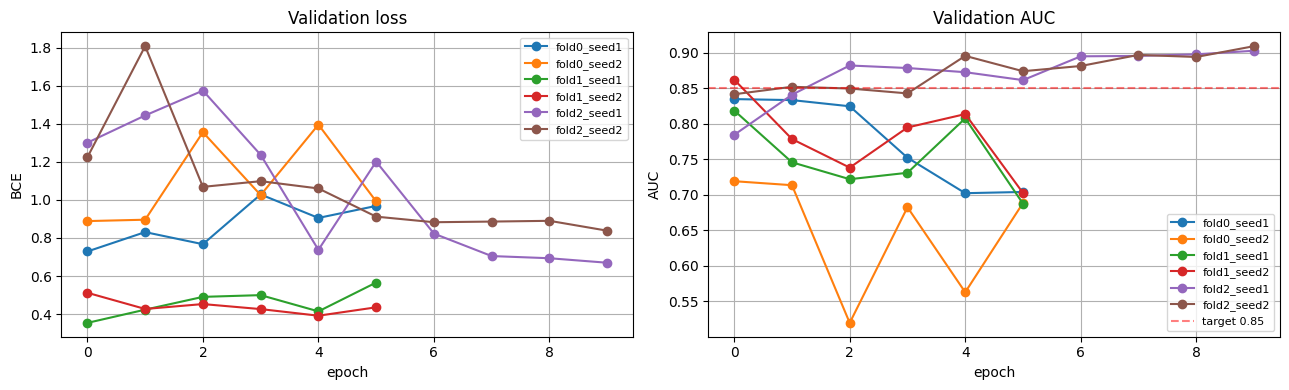

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for hp in sorted(glob.glob(str(OUT_DIR / "fold*_history.json"))):
    h = json.load(open(hp))["history"]
    label = Path(hp).stem.replace("_history", "")
    ax[0].plot([e["epoch"] for e in h], [e["va_loss"] for e in h], marker="o", label=label)
    ax[1].plot([e["epoch"] for e in h], [e["va_auc"]  for e in h], marker="o", label=label)
ax[0].set(title="Validation loss", xlabel="epoch", ylabel="BCE")
ax[1].set(title="Validation AUC",  xlabel="epoch", ylabel="AUC")
ax[1].axhline(0.85, color="red", linestyle="--", alpha=0.5, label="target 0.85")
for a in ax: a.legend(fontsize=8); a.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
fold_oofs = []
for fold in range(N_SPLITS):
    seed_oofs = []
    for seed in SEEDS:
        p = OUT_DIR / f"fold{fold}_seed{seed}_oof.csv"
        if p.exists(): seed_oofs.append(pd.read_csv(p))
    if not seed_oofs: continue
    base = seed_oofs[0][["Name", "patient_id", "y_true"]].copy()
    base["y_pred"] = np.mean([d["y_pred"].values for d in seed_oofs], axis=0)
    fold_oofs.append(base)
if fold_oofs:
    oof = pd.concat(fold_oofs, ignore_index=True)
    cell_auc = roc_auc_score(oof["y_true"], oof["y_pred"])
    pp = oof.groupby("patient_id").agg(
        mean_pred=("y_pred", "mean"), median_pred=("y_pred", "median"),
        label=("y_true", "first")).sort_values("mean_pred")
    pat_auc = roc_auc_score(pp["label"], pp["mean_pred"])
    print("=== OOF (seed-averaged) ===")
    print(pp.to_string())
    print(f"\ncell-level OOF AUC: {cell_auc:.4f}    patient-level AUC: {pat_auc:.4f}")

=== OOF (seed-averaged) ===
            mean_pred  median_pred  label
patient_id                               
7            0.097265     0.054862      0
10           0.160457     0.072721      0
15           0.237940     0.109187      0
13           0.270693     0.204472      0
11           0.323517     0.303702      0
14           0.423648     0.400830      0
17           0.565604     0.599272      1
5            0.606238     0.605618      1
9            0.670477     0.718417      0
16           0.700440     0.780996      1
3            0.773964     0.827438      1
18           0.891357     0.906465      1

cell-level OOF AUC: 0.8579    patient-level AUC: 0.9429


In [14]:
def _d4(bf, fl):
    for k in range(4):
        bfr = torch.rot90(bf, k, dims=(-2, -1))
        flr = torch.rot90(fl, k, dims=(-2, -1))
        yield bfr, flr
        yield TF.hflip(bfr), TF.hflip(flr)

def load_model_from_ckpt(ckpt_path):
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    args = state.get("args", {})
    dropout = float(args.get("dropout", DROPOUT))
    model = MultimodalClassifier(pretrained=False, dropout=dropout).to(DEVICE)
    model.load_state_dict(state["model"]); model.eval()
    return model

def predict_one_ckpt(ckpt_path, loader, tta=True):
    model = load_model_from_ckpt(ckpt_path)
    preds = []
    n_aug = 8 if tta else 1
    with torch.no_grad():
        for batch in loader:
            bf = batch["bf"].to(DEVICE, non_blocking=True)
            fl = batch["fl"].to(DEVICE, non_blocking=True)
            p = None
            for bf_t, fl_t in (_d4(bf, fl) if tta else [(bf, fl)]):
                with torch.amp.autocast("cuda", enabled=DEVICE == "cuda"):
                    pi = torch.sigmoid(model(bf_t, fl_t)).float()
                p = pi if p is None else p + pi
            preds.append((p / n_aug).cpu().numpy())
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.concatenate(preds)

test_ds = CachedCellDataset(df_test, bf_test_cache, fl_test_cache,
                            eval_modality_transform("bf"),
                            eval_modality_transform("fl"))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

ckpts_all = sorted(glob.glob(str(OUT_DIR / "fold*_best.pt")))
ckpts = []
for c in ckpts_all:
    s = torch.load(c, map_location="cpu", weights_only=False)
    va = s.get("val_auc")
    if va is not None and va >= ENSEMBLE_MIN_AUC:
        ckpts.append(c); print(f"  KEEP {Path(c).name}  val_auc={va:.4f}")
    else:
        print(f"  DROP {Path(c).name}  val_auc={va}")
if TRAIN_FULL_DATA_MODEL and (OUT_DIR / "fulldata_best.pt").exists():
    ckpts.append(str(OUT_DIR / "fulldata_best.pt"))
    print("  KEEP fulldata_best.pt (always included)")

if not ckpts:
    raise RuntimeError(f"No checkpoints passed the gate at {ENSEMBLE_MIN_AUC}")

all_preds = []
for c in ckpts:
    t0 = time.time()
    all_preds.append(predict_one_ckpt(c, test_loader, tta=True))
    print(f"  {Path(c).name} done in {time.time()-t0:.1f}s")
preds = np.mean(all_preds, axis=0)

sub = pd.DataFrame({"Name": df_test["Name"].values, "Diagnosis": preds})
sub.to_csv("/kaggle/working/submission.csv", index=False)
print(f"\nWrote submission.csv  (mean pred = {preds.mean():.3f}, "
      f"min {preds.min():.3f}, max {preds.max():.3f})")
print(sub.head())
!wc -l /kaggle/working/submission.csv

  KEEP fold0_seed1_best.pt  val_auc=0.8348
  DROP fold0_seed2_best.pt  val_auc=0.7192126050000001
  KEEP fold1_seed1_best.pt  val_auc=0.8188
  KEEP fold1_seed2_best.pt  val_auc=0.8622
  KEEP fold2_seed1_best.pt  val_auc=0.9029
  KEEP fold2_seed2_best.pt  val_auc=0.9093
  KEEP fulldata_best.pt (always included)
  fold0_seed1_best.pt done in 137.9s
  fold1_seed1_best.pt done in 137.6s
  fold1_seed2_best.pt done in 137.8s
  fold2_seed1_best.pt done in 138.0s
  fold2_seed2_best.pt done in 138.0s
  fulldata_best.pt done in 137.9s

Wrote submission.csv  (mean pred = 0.464, min 0.004, max 0.986)
          Name  Diagnosis
0  image_1.jpg   0.689092
1  image_2.jpg   0.350021
2  image_3.jpg   0.729630
3  image_4.jpg   0.378820
4  image_5.jpg   0.397466
59041 /kaggle/working/submission.csv
